<a href="https://colab.research.google.com/github/daze7/ML-project/blob/main/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
from math import floor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

In [ ]:
#uploading data
table = pd.read_csv("/content/Pune house data.csv")
table

,area_type,availability,size,society,total_sqft,bath,balcony,price,site_location
0,Super built-up Area,19-Dec,2 BHK,Coomee,1056,2.0,1.0,39.07,Alandi Road
1,Plot Area,Ready To Move,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,Ambegaon Budruk
2,Built-up Area,Ready To Move,3 BHK,NaN,1440,2.0,3.0,62.00,Anandnagar
3,Super built-up Area,Ready To Move,3 BHK,Soiewre,1521,3.0,1.0,95.00,Aundh
4,Super built-up Area,Ready To Move,2 BHK,NaN,1200,2.0,1.0,51.00,Aundh Road
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00,Pashan
13316,Super built-up Area,Ready To Move,4 BHK,NaN,3600,5.0,NaN,400.00,Paud Road
13317,Built-up Area,Ready To Move,2 BHK,Mahla T,1141,2.0,1.0,60.00,Pirangut
13318,Super built-up Area,18-Jun,4 BHK,SollyCl,4689,4.0,1.0,488.00,Prabhat Road


In [ ]:
#remove unnecessary attributes
table = table.drop("availability", axis=1)
table = table.drop("society", axis=1)
table

,area_type,size,total_sqft,bath,balcony,price,site_location
0,Super built-up Area,2 BHK,1056,2.0,1.0,39.07,Alandi Road
1,Plot Area,4 Bedroom,2600,5.0,3.0,120.00,Ambegaon Budruk
2,Built-up Area,3 BHK,1440,2.0,3.0,62.00,Anandnagar
3,Super built-up Area,3 BHK,1521,3.0,1.0,95.00,Aundh
4,Super built-up Area,2 BHK,1200,2.0,1.0,51.00,Aundh Road
...,...,...,...,...,...,...,...
13315,Built-up Area,5 Bedroom,3453,4.0,0.0,231.00,Pashan
13316,Super built-up Area,4 BHK,3600,5.0,NaN,400.00,Paud Road
13317,Built-up Area,2 BHK,1141,2.0,1.0,60.00,Pirangut
13318,Super built-up Area,4 BHK,4689,4.0,1.0,488.00,Prabhat Road


In [ ]:
#check null values
table.isnull().sum()

,0
area_type,0
size,16
total_sqft,0
bath,73
balcony,609
price,0
site_location,1


In [ ]:
#discard null values
table['balcony'] = table['balcony'].fillna('0')
table = table.dropna()
table.isnull().sum()
table.shape

(13246, 7)

In [ ]:
table['num_size'] = table['size'].apply(lambda x: int(x.split(' ')[0]))
table = table.drop("size", axis=1)
def sqft_fix(x):
    t = x.split('-')
    if len(t) == 2:
        return(float(t[0]) + float(t[1]))/2
    try:
        return float(x)
    except:
        return None
table["total_sqft"] = table["total_sqft"].apply(sqft_fix)
table

/tmp/ipykernel_3015/1371707556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['num_size'] = table['size'].apply(lambda x: int(x.split(' ')[0]))


,area_type,total_sqft,bath,balcony,price,site_location,num_size
0,Super built-up Area,1056.0,2.0,1.0,39.07,Alandi Road,2
1,Plot Area,2600.0,5.0,3.0,120.00,Ambegaon Budruk,4
2,Built-up Area,1440.0,2.0,3.0,62.00,Anandnagar,3
3,Super built-up Area,1521.0,3.0,1.0,95.00,Aundh,3
4,Super built-up Area,1200.0,2.0,1.0,51.00,Aundh Road,2
...,...,...,...,...,...,...,...
13315,Built-up Area,3453.0,4.0,0.0,231.00,Pashan,5
13316,Super built-up Area,3600.0,5.0,0,400.00,Paud Road,4
13317,Built-up Area,1141.0,2.0,1.0,60.00,Pirangut,2
13318,Super built-up Area,4689.0,4.0,1.0,488.00,Prabhat Road,4


In [ ]:
#check null values
table.isnull().sum()

,0
area_type,0
total_sqft,46
bath,0
balcony,0
price,0
site_location,0
num_size,0


In [ ]:
table = table.dropna()
table.isnull().sum()
table.shape
table['price_per_sqft'] = table['price'] * 100000 / table['total_sqft']
table = table[~(table.total_sqft/table.num_size<300)]
table.shape

/tmp/ipykernel_3015/1474781584.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['price_per_sqft'] = table['price'] * 100000 / table['total_sqft']


(12456, 8)

In [ ]:
def remove_pps_outliers(df):
    res = pd.DataFrame()
    for key, subdf in df.groupby('site_location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        res = pd.concat([res, reduced_df], ignore_index = True)
    return res

table = remove_pps_outliers(table)
table.shape

(10883, 8)

In [ ]:
def remove_num_size_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('site_location'):
        num_size_stats = {}
        for num_size, num_size_df in location_df.groupby('num_size'):
            num_size_stats[num_size] = {
                'mean' : np.mean(num_size_df.price_per_sqft),
                'std' : np.std(num_size_df.price_per_sqft),
                'count' : num_size_df.shape[0]
            }
        for num_size, num_size_df in location_df.groupby('num_size'):
            stats = num_size_stats.get(num_size-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, num_size_df[num_size_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices, axis ='index')

table = remove_num_size_outliers(table)
table.shape
table = table.drop("price_per_sqft", axis=1)

In [ ]:
dummy_cols = pd.get_dummies(table.area_type).drop('Super built-up  Area', axis='columns')
table = pd.concat([table,dummy_cols], axis='columns')
table = table.drop("area_type", axis=1)

table["site_location"].value_counts()
table["site_location"] = table["site_location"].astype('category')
table.dtypes
table["site_location"] = table["site_location"].cat.codes

#dummy_cols = pd.get_dummies(table.site_location).drop('Alandi Road', axis='columns')
#table = pd.concat([table,dummy_cols], axis='columns')
#table = table.drop("site_location", axis=1)
table

,total_sqft,bath,balcony,price,site_location,num_size,Built-up Area,Carpet Area,Plot Area
0,1056.0,2.0,1.0,39.07,0,2,False,False,False
1,2894.0,4.0,1.0,245.00,0,4,False,False,True
2,1084.0,2.0,2.0,50.00,0,2,False,False,False
3,1230.0,2.0,2.0,80.00,0,2,False,False,False
4,1750.0,3.0,2.0,130.00,0,3,False,False,False
...,...,...,...,...,...,...,...,...,...
10870,1165.0,2.0,1.0,67.00,95,2,False,False,False
10872,3122.0,6.0,2.0,250.00,95,4,False,False,False
10875,3500.0,6.0,0,115.00,95,6,True,False,False
10878,1050.0,2.0,2.0,54.00,95,2,False,False,False


In [ ]:
table.corr()["price"].sort_values(ascending=False)


,price
price,1.000000
total_sqft,0.921517
bath,0.641973
num_size,0.610434
Plot Area,0.191125
balcony,0.118014
Built-up Area,0.017445
Carpet Area,-0.012209
site_location,-0.015900


In [ ]:
#min-max scaling
table_col = table.columns.values
MMS = MinMaxScaler(copy=False).fit(table)
table = MMS.transform(table)
table = pd.DataFrame(table, columns=table_col)
table

,total_sqft,bath,balcony,price,site_location,num_size,Built-up Area,Carpet Area,Plot Area
0,0.025116,0.066667,0.333333,0.013909,0.0,0.066667,0.0,0.0,0.0
1,0.086179,0.200000,0.333333,0.112440,0.0,0.200000,0.0,0.0,1.0
2,0.026047,0.066667,0.666667,0.019139,0.0,0.066667,0.0,0.0,0.0
3,0.030897,0.066667,0.666667,0.033493,0.0,0.066667,0.0,0.0,0.0
4,0.048173,0.133333,0.666667,0.057416,0.0,0.133333,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
7538,0.028738,0.066667,0.333333,0.027273,1.0,0.066667,0.0,0.0,0.0
7539,0.093754,0.333333,0.666667,0.114833,1.0,0.200000,0.0,0.0,0.0
7540,0.106312,0.333333,0.000000,0.050239,1.0,0.333333,1.0,0.0,0.0
7541,0.024917,0.066667,0.666667,0.021053,1.0,0.066667,0.0,0.0,0.0


array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='total_sqft', ylabel='price'>,
        <Axes: xlabel='bath', ylabel='price'>,
        <Axes: xlabel='num_size', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='total_sqft'>,
        <Axes: xlabel='total_sqft', ylabel='total_sqft'>,
        <Axes: xlabel='bath', ylabel='total_sqft'>,
        <Axes: xlabel='num_size', ylabel='total_sqft'>],
       [<Axes: xlabel='price', ylabel='bath'>,
        <Axes: xlabel='total_sqft', ylabel='bath'>,
        <Axes: xlabel='bath', ylabel='bath'>,
        <Axes: xlabel='num_size', ylabel='bath'>],
       [<Axes: xlabel='price', ylabel='num_size'>,
        <Axes: xlabel='total_sqft', ylabel='num_size'>,
        <Axes: xlabel='bath', ylabel='num_size'>,
        <Axes: xlabel='num_size', ylabel='num_size'>]], dtype=object)

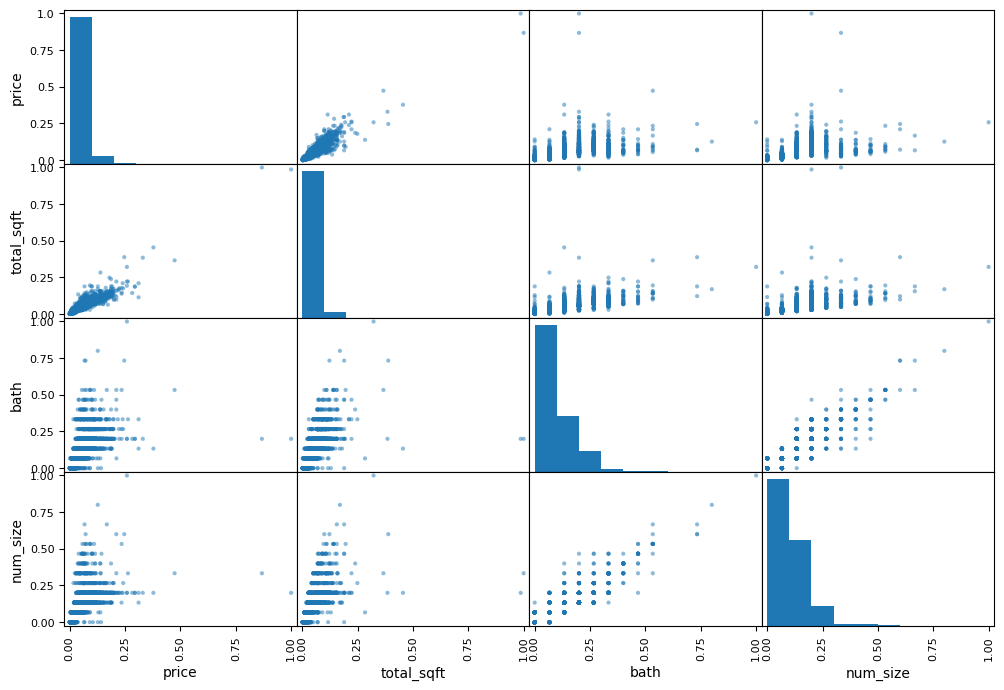

In [ ]:
#graphics
scatter_matrix(table[["price", "total_sqft",
                     "bath", "num_size"]], figsize=(12, 8))

In [ ]:
#split train test
table_labels = table['price'].copy()
table_ready = table.drop('price', axis='columns')
train_set, test_set, train_labels, test_labels = train_test_split(table_ready, table_labels, test_size = 0.2, random_state = 42)
train_set.head()



,total_sqft,bath,balcony,site_location,num_size,Built-up Area,Carpet Area,Plot Area
5461,0.024917,0.000000,0.333333,0.726316,0.000000,0.0,0.0,0.0
7538,0.028738,0.066667,0.333333,1.000000,0.066667,0.0,0.0,0.0
5751,0.023256,0.066667,0.333333,0.768421,0.066667,0.0,0.0,0.0
2586,0.027907,0.066667,0.666667,0.347368,0.066667,0.0,0.0,0.0
259,0.040565,0.133333,0.333333,0.031579,0.133333,0.0,0.0,0.0


In [ ]:
#learning curves
def plot_learning_curves(model):
    X_train = train_set.values
    X_val = test_set.values
    y_train = train_labels.values
    y_val = test_labels.values
    train_errors, val_errors = [], []
    for m in range(1, len(X_train) // 8):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train_predict, y_train[:m]))
        val_errors.append(mean_squared_error(y_val_predict, y_val))
    plt.plot(np.sqrt(train_errors) , "r-+", linewidth=1, label="train")
    plt.plot(np.sqrt(val_errors) , "b-", linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)



In [ ]:
def display_scores(model, t_set):
    scores = cross_val_score(model, t_set, train_labels, scoring="neg_mean_squared_error", cv=10)
    rmse_scores = np.sqrt(-scores)
    print("Scores:", rmse_scores)
    print("Average:", rmse_scores.mean())
    print("Standard deviation:", rmse_scores.std(), "\n")

Train set:

Predictions: [0.02325407 0.02773283 0.02208574 0.02705058 0.040113  ]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.013555586443796612 

Test set:

Predictions: [0.01718381 0.03004695 0.03244494 0.03536181 0.02820693]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.012791044924997235 

Cross Validation:

Scores: [0.01423597 0.01334382 0.01634227 0.01238261 0.01168626 0.01289523
 0.01468245 0.01353159 0.01528776 0.01295365]
Average: 0.01373416014639473
Standard deviation: 0.0013376821601696304 

Learning curves:


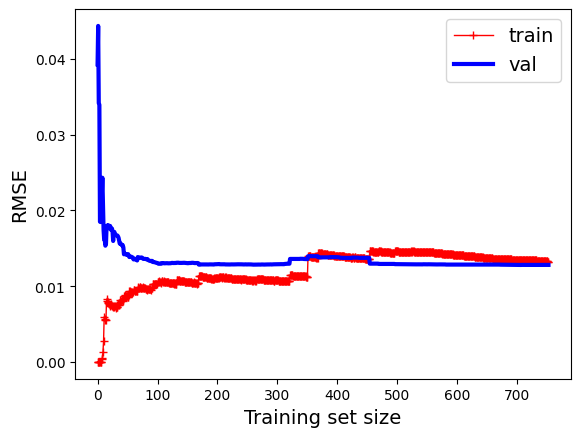

In [ ]:
#linear regression
lin_reg = LinearRegression()
lin_reg.fit(train_set, train_labels)
print("Train set:\n")
lin_reg_res = lin_reg.predict(train_set)
print("Predictions:", lin_reg_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, lin_reg_res)), '\n')
print("Test set:\n")
lin_reg_res = lin_reg.predict(test_set)
print("Predictions:", lin_reg_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, lin_reg_res)), '\n')
print("Cross Validation:\n")
display_scores(lin_reg, train_set)
print("Learning curves:")
plot_learning_curves(lin_reg)
#underfitting

Train set:

Predictions: [0.02644338 0.02653152 0.01942918 0.02280031 0.04400957]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.009348532667195923 

Test set:

Predictions: [0.01649751 0.02793475 0.02846999 0.03687591 0.02576238]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.12020679824163277 

Cross Validation:

Scores: [2.04725805e+00 1.90758615e+00 1.48524287e+02 5.18911143e-02
 4.26887384e-02 3.16137205e+00 3.41856311e-02 3.20808550e+01
 2.83176525e-02 7.70450965e-01]
Average: 18.864889237439943
Standard deviation: 44.21337935232954 

Learning curves:


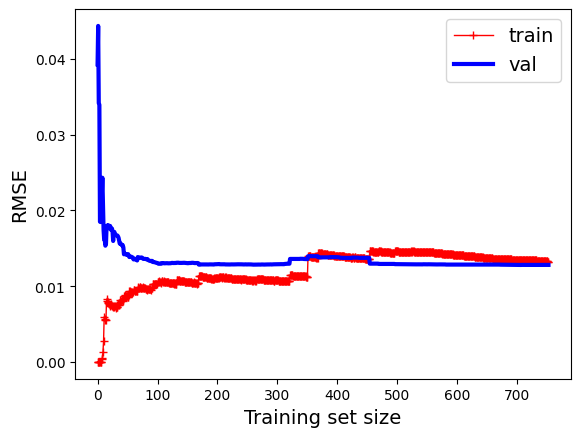

In [ ]:
poly_features = PolynomialFeatures(degree=5, include_bias=False)
train_set_poly = poly_features.fit_transform(train_set)
test_set_poly = poly_features.fit_transform(test_set)
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(train_set_poly, train_labels)
print("Train set:\n")
lin_reg_poly_res = lin_reg_poly.predict(train_set_poly)
print("Predictions:", lin_reg_poly_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, lin_reg_poly_res)), '\n')
print("Test set:\n")
lin_reg_poly_res = lin_reg_poly.predict(test_set_poly)
print("Predictions:", lin_reg_poly_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, lin_reg_poly_res)), '\n')
print("Cross Validation:\n")
display_scores(lin_reg_poly, train_set_poly)
print("Learning curves:")
plot_learning_curves(lin_reg_poly)
#underfitting when the degree is increased, the model is retrained

Train set:

Predictions: [0.01035116 0.02474681 0.02587475 0.02738889 0.04265862]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.01788167272922182 

Test set:

Predictions: [0.01915526 0.02808072 0.02886224 0.02717975 0.02681843]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.017680946033848868 

Cross Validation:

Scores: [0.02074831 0.01739376 0.01688486 0.01756089 0.01575205 0.01692871
 0.02038097 0.02439463 0.02178602 0.01757214]
Average: 0.018940233910739658
Standard deviation: 0.002603745694328629 

Learning curves:


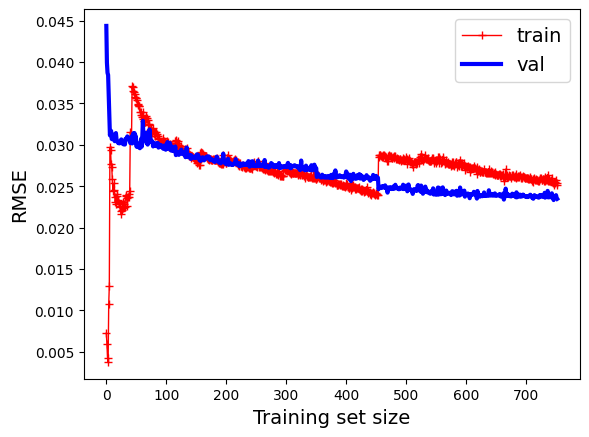

In [ ]:
#stochastic gradient descent
sgd_reg = SGDRegressor(max_iter=250, penalty=None, eta0=0.1)
sgd_reg.fit(train_set_poly, train_labels)
print("Train set:\n")
sgd_reg_res = sgd_reg.predict(train_set_poly)
print("Predictions:", sgd_reg_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, sgd_reg_res)), '\n')
print("Test set:\n")
sgd_reg_res = sgd_reg.predict(test_set_poly)
print("Predictions:", sgd_reg_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, sgd_reg_res)), '\n')
print("Cross Validation:\n")
display_scores(sgd_reg, train_set_poly)
print("Learning curves:")
plot_learning_curves(sgd_reg)
#the result improved

Train set:

Predictions: [0.01967225 0.02662014 0.02135536 0.01706062 0.04230582]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.005320746609115075 

Test set:

Predictions: [0.01602938 0.02467603 0.02947057 0.0360156  0.02059498]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.011745652485642969 

Cross Validation:

Scores: [0.02173794 0.01960239 0.0305171  0.01967911 0.01681977 0.02118589
 0.0217964  0.03724626 0.02359693 0.01956673]
Average: 0.02317485080671955
Standard deviation: 0.005817219879227629 

Learning curves:


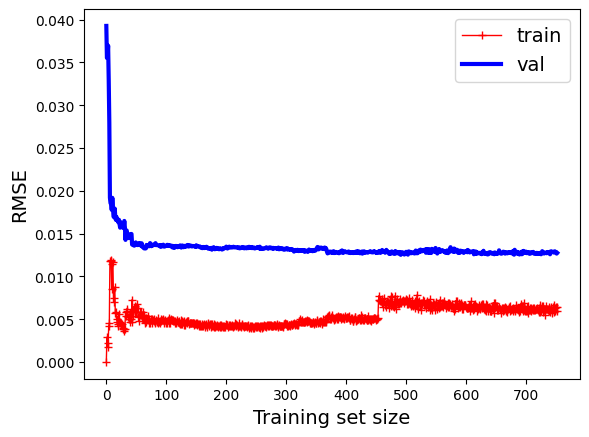

In [ ]:
#random forest regressor
forest_reg = RandomForestRegressor()
forest_reg.fit(train_set, train_labels)
print("Train set:\n")
forest_reg_res = forest_reg.predict(train_set)
print("Predictions:", forest_reg_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, forest_reg_res)), '\n')
print("Test set:\n")
forest_reg_res = forest_reg.predict(test_set)
print("Predictions:", forest_reg_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, forest_reg_res)), '\n')
print("Cross Validation:\n")
display_scores(sgd_reg, train_set)
print("Learning curves:")
plot_learning_curves(forest_reg)
#the result is slightly better, but the running time has increased dramatically

Train set:

Predictions: [0.01626794 0.02727273 0.02296651 0.01578947 0.04060048]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.0010716414221729502 

Test set:

Predictions: [0.01284689 0.02296651 0.02966507 0.03923445 0.01497608]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.016984626757457075 

Cross Validation:

Scores: [0.02006781 0.01860052 0.01937713 0.01408946 0.01557639 0.01481653
 0.01553474 0.01597646 0.01764986 0.01625142]
Average: 0.01679403372946701
Standard deviation: 0.0019142206089632014 

Learning curves:


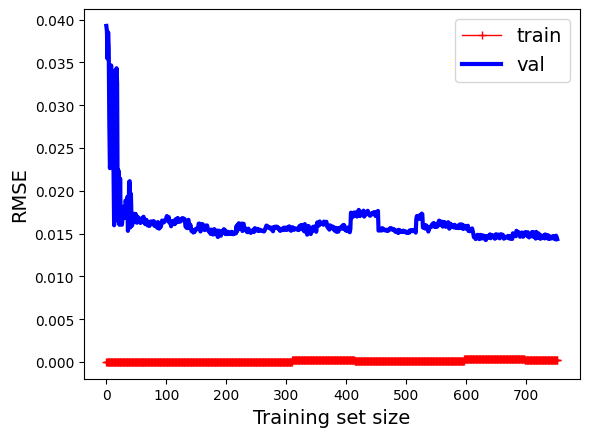

In [ ]:
#Decision tree
dtr = DecisionTreeRegressor()
dtr.fit(train_set, train_labels)
print("Train set:\n")
dtr_res = dtr.predict(train_set)
print("Predictions:", dtr_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, dtr_res)), '\n')
print("Test set:\n")
dtr_res = dtr.predict(test_set)
print("Predictions:", dtr_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, dtr_res)), '\n')
print("Cross Validation:\n")
display_scores(dtr, train_set)
print("Learning curves:")
plot_learning_curves(dtr)
#overfitting

Train set:

Predictions: [0.01284689 0.02296651 0.02966507 0.03923445 0.01497608]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.011449096708744175 

Test set:

Predictions: [0.01211692 0.02751563 0.03385745 0.03385745 0.02751563]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.012240520937782303 

Cross Validation:

Scores: [0.01501623 0.01276789 0.01470484 0.01101796 0.01167357 0.01173662
 0.01405371 0.02291603 0.01465723 0.01246771]
Average: 0.014101179195861712
Standard deviation: 0.0032349840882202213 

Learning curves:


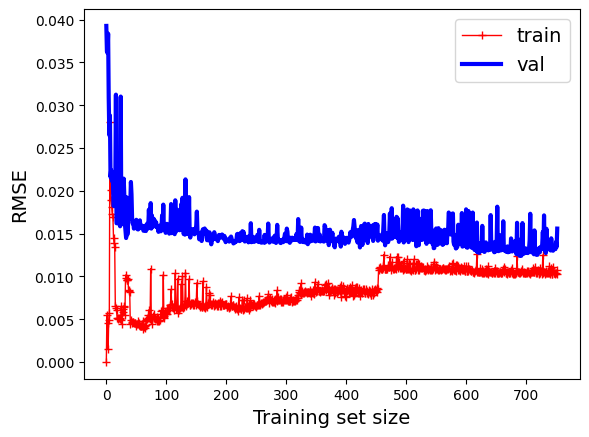

In [ ]:
#Decision tree + hyperparameters
hyperparameters = [{'max_depth': [20, 21, 22, 23], 'min_samples_leaf': [2, 3, 4, 5],
               'min_samples_split': [2, 4, 6, 8], 'max_features': [6, 7, 8, 9],
               'max_leaf_nodes': [23, 24, 25, 26]}]
dtr = DecisionTreeRegressor()
dtr_hp = GridSearchCV(dtr, hyperparameters, cv=10, scoring='neg_mean_squared_error')
dtr_hp.fit(train_set, train_labels)
print("Train set:\n")
dtr_hp_res = dtr_hp.best_estimator_.predict(train_set)
print("Predictions:", dtr_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, dtr_hp_res)), '\n')
print("Test set:\n")
dtr_hp_res = dtr_hp.best_estimator_.predict(test_set)
print("Predictions:", dtr_hp_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, dtr_hp_res)), '\n')
print("Cross Validation:\n")
display_scores(dtr_hp.best_estimator_, train_set)
print("Learning curves:")
plot_learning_curves(dtr_hp.best_estimator_)
#the result is slightly better, but the running time has increased dramatically

Train set:

Predictions: [0.03951951 0.03999376 0.03916546 0.03999276 0.04710769]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.018242130265510414 

Test set:

Predictions: [0.04255904 0.04504804 0.04507709 0.04504804 0.04037574]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.018895377446295707 

Cross Validation:

Scores: [0.01559293 0.02052752 0.02087317 0.01905633 0.01530954 0.02045784
 0.0172509  0.01609422 0.01878615 0.01999747]
Average: 0.018394606647140637
Standard deviation: 0.002051261433172963 

Learning curves:


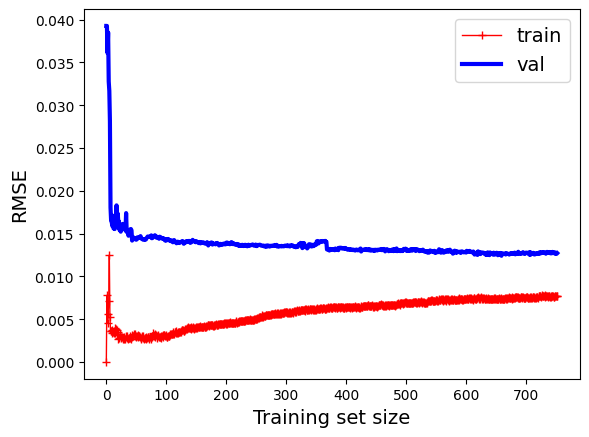

In [ ]:
#Decision tree + hyperparameters + adaboost
abr = AdaBoostRegressor(dtr_hp.best_estimator_, n_estimators=150, learning_rate=0.5, loss='square')
abr.fit(train_set, train_labels)
print("Train set:\n")
abr_res = abr.predict(train_set)
print("Predictions:", abr_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, abr_res)), '\n')
print("Test set:\n")
abr_res = abr.predict(test_set)
print("Predictions:", abr_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, abr_res)), '\n')
print("Cross Validation:\n")
display_scores(abr, train_set)
print("Learning curves:")
plot_learning_curves(abr)

Train set:

Predictions: [0.09146856 0.08690069 0.09512189 0.10567542 0.09905224]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.06657555507756366 

Test set:

Predictions: [0.05073157 0.10348771 0.10424644 0.09581337 0.09686389]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.06699974995997099 

Cross Validation:

Scores: [0.06652354 0.067061   0.06460726 0.06669857 0.06592556 0.06732698
 0.06677296 0.06473226 0.06479632 0.07139601]
Average: 0.0665840449723376
Standard deviation: 0.0018695805129602637 

Learning curves:


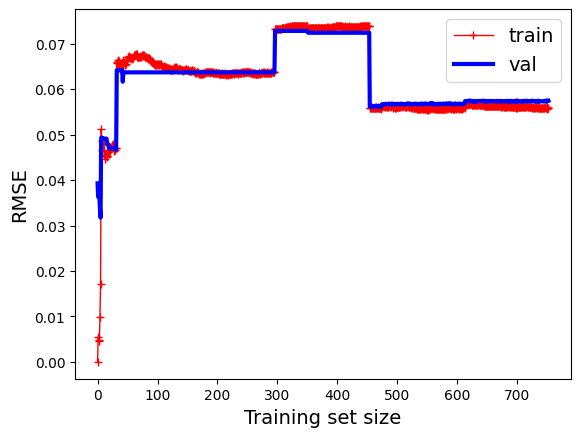

In [ ]:
#Support Vector Machines
svr = SVR(kernel="poly", degree=2, C=150, epsilon=0.1)
svr.fit(train_set, train_labels)
print("Train set:\n")
svr_res = svr.predict(train_set)
print("Predictions:", svr_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, svr_res)), '\n')
print("Test set:\n")
svr_res = svr.predict(test_set)
print("Predictions:", svr_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, svr_res)), '\n')
print("Cross Validation:\n")
display_scores(svr, train_set)
print("Learning curves:")
plot_learning_curves(svr)

Train set:

Predictions: [0.01928605 0.02756182 0.02327609 0.02749393 0.04233998]
Labels: [np.float64(0.016267942583732056), np.float64(0.02727272727272727), np.float64(0.022966507177033493), np.float64(0.015789473684210527), np.float64(0.04066985645933015)]
RMSE: 0.014618959024951214 

Test set:

Predictions: [0.01758507 0.02943711 0.03170689 0.0334561  0.0279789 ]
Labels: [np.float64(0.008133971291866028), np.float64(0.03110047846889952), np.float64(0.02631578947368421), np.float64(0.029665071770334926), np.float64(0.023669856459330143)]
RMSE: 0.013797167525028539 

Cross Validation:

Scores: [0.01511193 0.01451884 0.01362546 0.01378029 0.01225427 0.0137423
 0.01623897 0.01870156 0.01726153 0.01342527]
Average: 0.014866039911578463
Standard deviation: 0.0018813138129261543 

Learning curves:


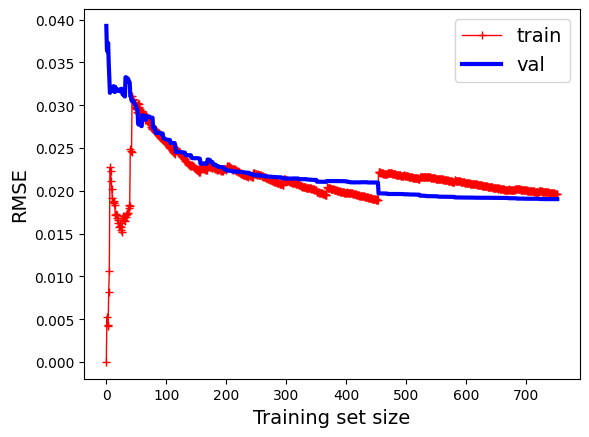

In [ ]:
ridge_reg = Ridge(alpha=1, solver = "cholesky")
ridge_reg.fit(train_set, train_labels)
print("Train set:\n")
ridge_reg_res = ridge_reg.predict(train_set)
print("Predictions:", ridge_reg_res[:5])
print("Labels:", list(train_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(train_labels, ridge_reg_res)), '\n')
print("Test set:\n")
ridge_reg_res = ridge_reg.predict(test_set)
print("Predictions:", ridge_reg_res[:5])
print("Labels:", list(test_labels.values)[:5])
print("RMSE:", np.sqrt(mean_squared_error(test_labels, ridge_reg_res)), '\n')
print("Cross Validation:\n")
display_scores(ridge_reg, train_set)
print("Learning curves:")
plot_learning_curves(ridge_reg)